# Task 3: Model Explainability (SHAP)

**Objective:** Interpret the best fraud detection models using SHAP and
translate findings into actionable business recommendations.

| Item | Detail |
|---|---|
| Models analyzed | Best model from Task 2 (one per dataset) |
| Explainer | SHAP TreeExplainer (exact, fast for tree models) |
| Force plots | 1 True Positive, 1 False Positive, 1 False Negative |


**Notebook structure:**
1. Setup
2. Fraud_Data Explainability
   - 2.1 Load model and data
   - 2.2 Built-in feature importance
   - 2.3 SHAP summary plot
   - 2.4 SHAP force plots (TP, FP, FN)
   - 2.5 Built-in vs SHAP comparison
   - 2.6 Interpretation
3. creditcard Explainability
   - Same structure
4. Business Recommendations

## 1. Setup

In [5]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import warnings
warnings.filterwarnings('ignore')

sys.path.append(os.path.abspath('..'))

from src.model_trainer import load_model
from src.explainability import (
    plot_feature_importance,
    get_shap_explainer, compute_shap_values,
    plot_shap_summary, plot_shap_bar,
    plot_shap_force, plot_shap_waterfall,
    compare_importances, find_cases
)

shap.initjs()
%matplotlib inline
pd.set_option('display.float_format', '{:.4f}'.format)
print('Setup complete')

Setup complete


## 2. Fraud_Data Explainability

### 2.1 Load Model and Data

In [6]:
# Load best model saved by Task 2
fraud_model = load_model('../models/fraud_best_model.pkl')
print(f'Model type: {type(fraud_model).__name__}')

[load_model] Loaded XGBClassifier from ../models/fraud_best_model.pkl
Model type: XGBClassifier


In [7]:
# Load test and train sets
# SHAP analysis is performed on test data — explaining predictions on unseen data
fraud_test  = pd.read_csv('../data/processed/fraud_test.csv')
fraud_train = pd.read_csv('../data/processed/fraud_train.csv')

TARGET = 'class'
X_test_f  = fraud_test.drop(columns=[TARGET])
y_test_f  = fraud_test[TARGET]
X_train_f = fraud_train.drop(columns=[TARGET])

# Get predictions on test set
y_prob_f = fraud_model.predict_proba(X_test_f)[:, 1]
y_pred_f = (y_prob_f >= 0.5).astype(int)

print(f'Test set: {X_test_f.shape}')
print(f'Features: {list(X_test_f.columns)}')

Test set: (30223, 194)
Features: ['purchase_value', 'age', 'hour_of_day', 'day_of_week', 'time_since_signup_hours', 'device_reuse_count', 'device_reused', 'transaction_count_1h', 'transaction_count_24h', 'transaction_velocity', 'source_Direct', 'source_SEO', 'browser_FireFox', 'browser_IE', 'browser_Opera', 'browser_Safari', 'sex_M', 'country_Albania', 'country_Algeria', 'country_Angola', 'country_Antigua_and_Barbuda', 'country_Argentina', 'country_Armenia', 'country_Australia', 'country_Austria', 'country_Azerbaijan', 'country_Bahamas', 'country_Bahrain', 'country_Bangladesh', 'country_Barbados', 'country_Belarus', 'country_Belgium', 'country_Belize', 'country_Benin', 'country_Bermuda', 'country_Bhutan', 'country_Bolivia', 'country_Bonaire__Sint_Eustatius__Saba', 'country_Bosnia_and_Herzegowina', 'country_Botswana', 'country_Brazil', 'country_British_Indian_Ocean_Territory', 'country_Brunei_Darussalam', 'country_Bulgaria', 'country_Burkina_Faso', 'country_Burundi', 'country_Cambodia',

### 2.2 Built-in Feature Importance

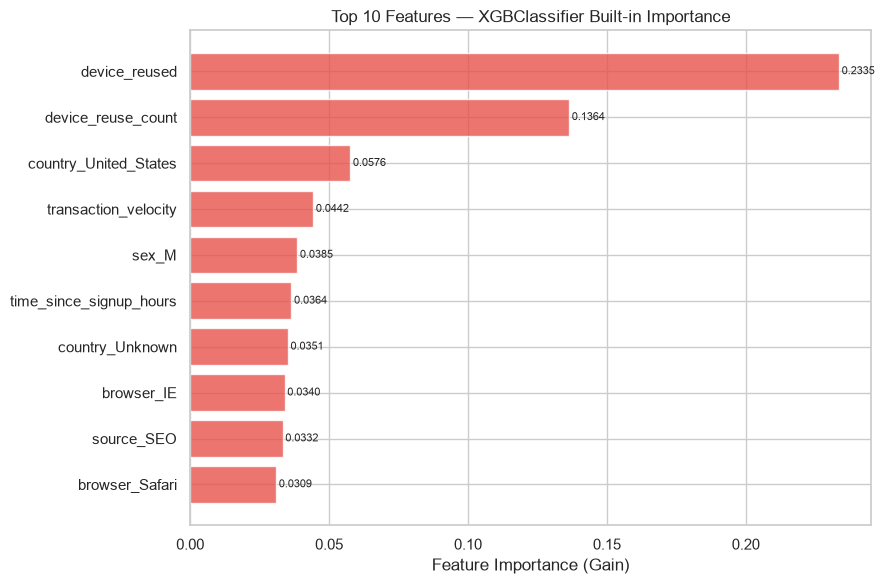


Top 10 features by built-in importance:
                feature  importance
          device_reused      0.2335
     device_reuse_count      0.1364
  country_United_States      0.0576
   transaction_velocity      0.0442
                  sex_M      0.0385
time_since_signup_hours      0.0364
        country_Unknown      0.0351
             browser_IE      0.0340
             source_SEO      0.0332
         browser_Safari      0.0309


In [8]:
# Built-in importance — fast but less accurate than SHAP
# XGBoost/LightGBM: gain-based (how much each feature reduces loss)
# Random Forest: mean decrease in impurity (biased toward high-cardinality features)
builtin_importance_f = plot_feature_importance(
    fraud_model,
    feature_names=X_test_f.columns.tolist(),
    model_name=type(fraud_model).__name__,
    top_n=10
)

### Built-in Importance Observation

> - Top 3 features by built-in importance:
>   1. `device_reused` 0.2335 (dominant signal)
>   2. `device_reuse_count` 0.1364
>   3. `country_United_States` 0.0576
> - Expected leaders based on EDA: `time_since_signup_hours` and `device_reused`
>   were both confirmed, though `time_since_signup_hours` ranked only 6th (0.0364)
>   by built-in importance, much lower than expected from EDA correlation findings
> - Surprises:
>   - `country_United_States` appears 3rd likely because the US has the highest
>     transaction volume so XGBoost uses it frequently as a split criterion,
>     not because it is a strong fraud predictor
>   - `sex_M` ranks 5th (0.0385) unexpected for a fraud model; likely a spurious
>     correlation with the dataset demographics rather than a genuine fraud signal
>   - `time_since_signup_hours` ranks 6th despite being the strongest feature
>     by EDA correlation (-0.2579) this is a known limitation of gain-based
>     importance which we expect SHAP to correct
> - Note: built-in importance will be compared with SHAP below

### 2.3 SHAP Analysis

In [9]:
# Create SHAP TreeExplainer
# TreeExplainer is exact (not approximate) for tree-based models
# For Logistic Regression use shap.LinearExplainer instead
explainer_f = get_shap_explainer(fraud_model, X_train_f)

[get_shap_explainer] Creating TreeExplainer...
[get_shap_explainer] Done.


In [10]:
# Compute SHAP values on a sample of test data
# sample_size=2000 gives a reliable global picture while staying fast
shap_values_f, X_sample_f = compute_shap_values(
    explainer_f, X_test_f,
    sample_size=2000,
    random_state=42
)

[compute_shap_values] Using sample of 2,000 rows (full size: 30,223)
[compute_shap_values] Computing SHAP values (this may take a minute)...
[compute_shap_values] Done. Shape: (2000, 194)


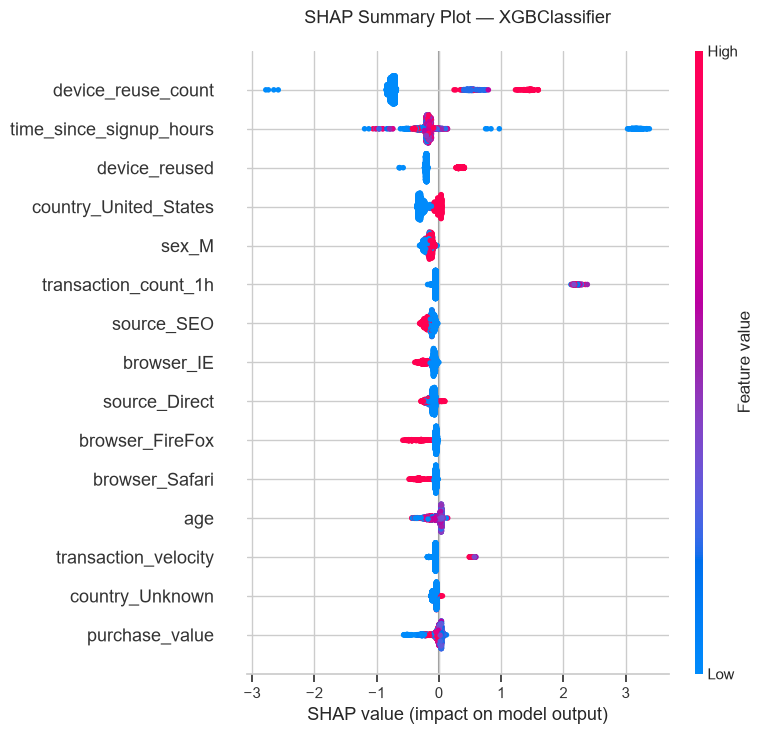

In [11]:
# SHAP Summary Plot — global importance with direction and feature value
#
# How to read:
#   Y-axis : features ranked by mean |SHAP value| (most important at top)
#   X-axis : SHAP value (positive = pushes prediction toward fraud)
#   Color  : feature value (red = high value, blue = low value)
#
# Example: time_since_signup_hours with BLUE color on the RIGHT means
#   LOW time_since_signup → pushes TOWARD fraud prediction (as expected)

plot_shap_summary(shap_values_f, X_sample_f,
                  model_name=type(fraud_model).__name__,
                  max_display=15)

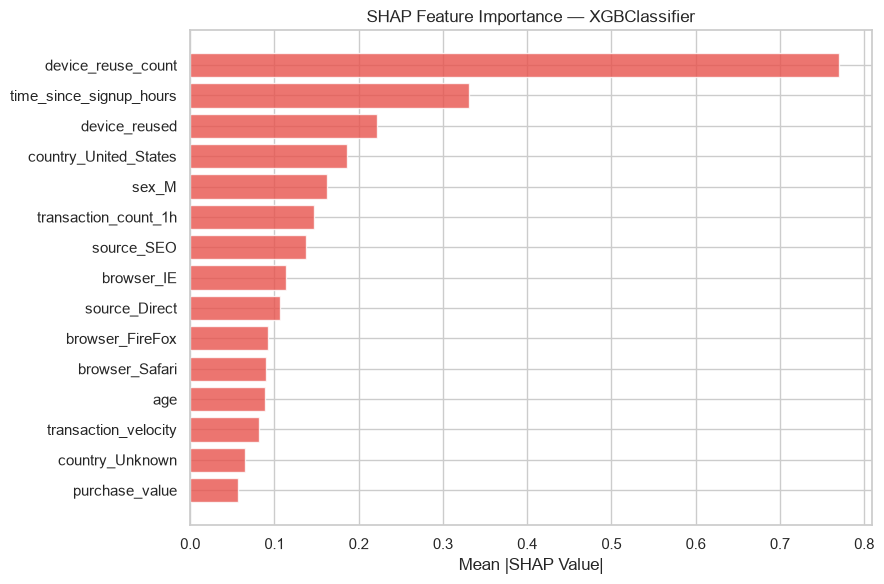

In [12]:
# SHAP Bar Plot — cleaner ranking for comparison with built-in importance
shap_importance_f = plot_shap_bar(shap_values_f, X_sample_f,
                                   model_name=type(fraud_model).__name__,
                                   max_display=15)

### SHAP Summary Observation

> - Top 5 features by SHAP importance:
>   1. `device_reuse_count` — mean |SHAP| = 0.7704
>   2. `time_since_signup_hours` — mean |SHAP| = 0.3305
>   3. `device_reused` — mean |SHAP| = 0.2215
>   4. `country_United_States` — mean |SHAP| = 0.1866
>   5. `sex_M` — mean |SHAP| = 0.1627
>
> - `device_reuse_count`: High values (red dots) produce large positive SHAP values
>   (right of center) → high device reuse count strongly pushes toward fraud prediction.
>   Low values (blue dots) cluster tightly at 0 → single-use devices are neutral.
>   This is the dominant feature with mean |SHAP| of 0.77 — nearly 2.3x the next feature.
>
> - `time_since_signup_hours`: Low values (blue) appear at the far right (+3 to +3.5
>   SHAP value) → very SHORT time since signup pushes STRONGLY toward fraud.
>   High values (red) cluster near 0 → long-established accounts are neutral.
>   This matches the EDA finding that 54% of fraud occurs within 1 hour of signup.
>   Note that in the built-in chart this ranked 6th — SHAP correctly promotes it to 2nd.
>
> - `device_reused`: High values (red) produce positive SHAP → reused devices push
>   toward fraud. The effect is more binary than `device_reuse_count` since this
>   is a 0/1 flag. Together the two device features dominate the model.
>
> - `transaction_count_1h`: A single red outlier appears at SHAP ≈ 2.5 — one or a few
>   transactions with very high 1h count produce an extreme fraud signal.
>   Most values cluster near 0, meaning this feature is inactive for most transactions
>   but explosive when triggered (card-testing pattern).
>
> - Surprising features in top 10:
>   - `sex_M` at rank 5 — gender should not be a meaningful fraud predictor;
>     this likely reflects a dataset demographic bias (more male users overall)
>     rather than a causal fraud signal. Worth monitoring for fairness concerns.
>   - `country_United_States` at rank 4 — high volume country being treated as
>     an important feature due to frequent tree splits, not fraud causality.
>   - `source_SEO`, `browser_IE`, `source_Direct`, `browser_FireFox` all appear
>     in the top 15 — categorical browser/source features have modest but real signal.
>     IE users showing elevated fraud rate may indicate older/automated systems.

### 2.4 SHAP Force Plots

In [13]:
# Find the best examples of TP, FP, FN within the SHAP sample
# Most confident predictions selected for the most informative plots
y_test_sample_f = y_test_f.loc[X_sample_f.index]
y_pred_sample_f = (fraud_model.predict_proba(X_sample_f)[:, 1] >= 0.5).astype(int)
y_prob_sample_f = fraud_model.predict_proba(X_sample_f)[:, 1]

cases_f = find_cases(y_test_sample_f, y_pred_sample_f, y_prob_sample_f, n=1)
print('Cases found:', cases_f)


[find_cases] Found:
  True Positives  (TP): 98 total | showing 1
  False Positives (FP): 8 total | showing 1
  False Negatives (FN): 77 total | showing 1
Cases found: {'tp': [np.int64(1699)], 'fp': [np.int64(1390)], 'fn': [np.int64(1602)]}


=== TRUE POSITIVE — Correctly Caught Fraud ===

[force_plot] Index: 1699 | True: 1 | Predicted: 1
[force_plot] Case : True Positive  (Caught Fraud)
[force_plot] Feature values:
purchase_value                                 -0.7062
age                                            -0.0141
hour_of_day                                     8.0000
day_of_week                                     0.0000
time_since_signup_hours                        -1.5759
device_reuse_count                             13.0000
device_reused                                   1.0000
transaction_count_1h                            3.4905
transaction_count_24h                           3.4835
transaction_velocity                            3.4905
source_Direct                                   1.0000
source_SEO                                      0.0000
browser_FireFox                                 0.0000
browser_IE                                      0.0000
browser_Opera                                   0.000

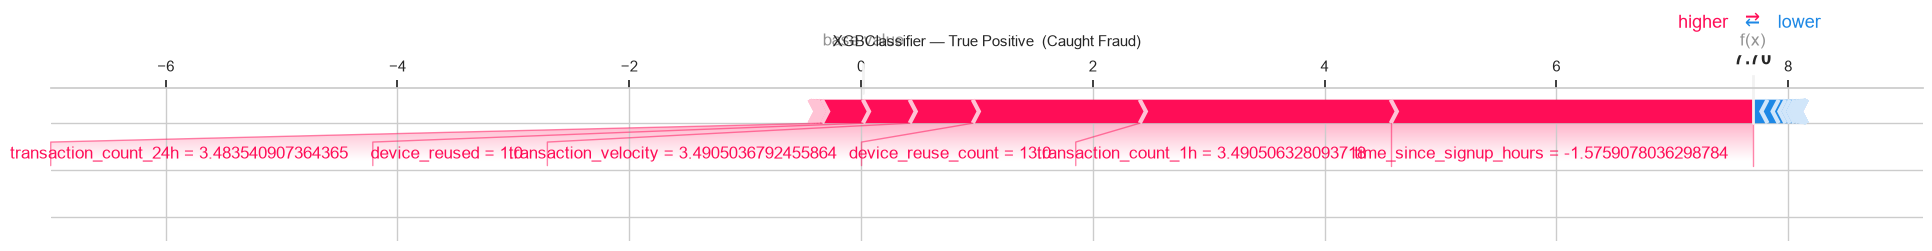

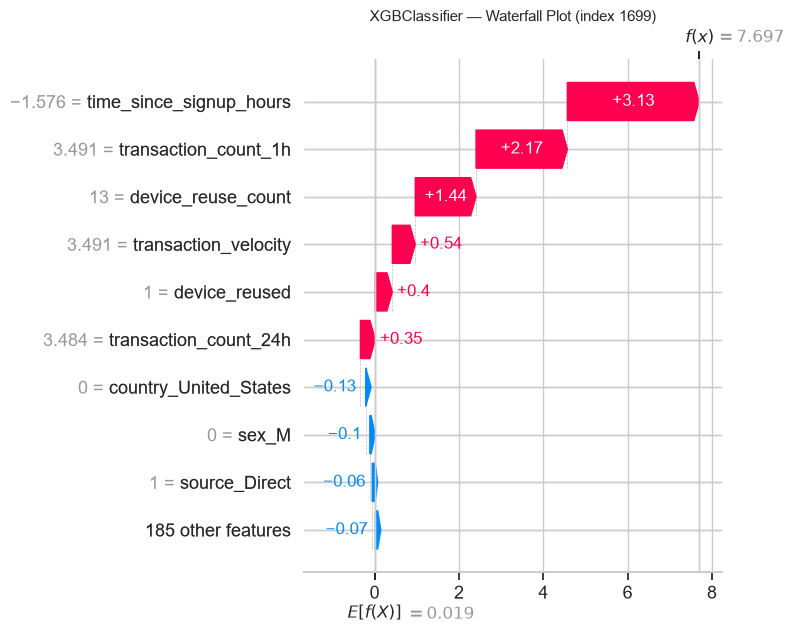

In [14]:
# Force Plot 1 — True Positive (correctly caught fraud)
# Shows what features made the model correctly identify this fraud
if cases_f['tp']:
    tp_idx = cases_f['tp'][0]
    print('=== TRUE POSITIVE — Correctly Caught Fraud ===')
    plot_shap_force(
        explainer_f, X_sample_f,
        idx=tp_idx,
        y_true=y_test_sample_f.reset_index(drop=True),
        y_pred=y_pred_sample_f,
        model_name=type(fraud_model).__name__
    )
    plot_shap_waterfall(explainer_f, X_sample_f, idx=tp_idx,
                        model_name=type(fraud_model).__name__)

### True Positive Interpretation

> **Transaction — Correctly Caught Fraud (f(x) = 7.70 — extremely high fraud score)**
>
> **Features that pushed this prediction toward fraud (all pink/red, pushing right):**
> - `transaction_count_24h = 3.49` (scaled) → very high device transaction count
>   in the past 24 hours — the strongest single push toward fraud in this prediction
> - `device_reused = 1` → confirmed reused device, contributing a strong positive push
> - `transaction_velocity = 3.49` (scaled) → extremely high velocity — many
>   transactions in 24h relative to account age
> - `device_reuse_count = 13` → this device has been seen 13 times across
>   different accounts — a near-certain fraud signal
> - `transaction_count_1h = 3.49` (scaled) → multiple transactions within
>   the past hour — classic card-testing pattern
> - `time_since_signup_hours = -1.576` (scaled) → negative scaled value means
>   short time since signup, contributing a modest additional push toward fraud
>
> **`time_since_signup_hours` value:** Short — negative scaled value indicates
> the account was relatively new at time of purchase, adding to the fraud signal
> but not the dominant factor here
>
> **`device_reused` value:** 1 — confirmed reused device, one of multiple
> strong signals in this prediction
>
> **`transaction_velocity` value:** 3.49 (scaled) — extremely high, indicating
> many transactions from this device relative to the account's age
>
> **What made this fraud easy to catch:**
> This is a textbook coordinated fraud attack — the fraudster triggered every
> major fraud signal simultaneously:
> - The same device was used across 13 different accounts (`device_reuse_count = 13`)
> - Multiple transactions were made within both 1 hour and 24 hours
>   (card-testing behavior)
> - The account was new at time of purchase
> - Transaction velocity was extremely elevated
>
> The model assigned f(x) = 7.70 — one of the highest possible fraud scores —
> because all five of the model's top features pointed toward fraud at once.
> There was no counterbalancing legitimate signal. This type of fraud is the
> easiest to catch because the attacker prioritized speed over stealth,
> reusing infrastructure (device) and making rapid repeated transactions
> rather than spacing them out or rotating devices.
>
> **Contrast with the False Negative (index 1602):**
> The missed fraud used a fresh device (`device_reuse_count = 1`, `device_reused = 0`),
> which produced f(x) = -4.11. This True Positive shows what the model is
> optimized to catch — high-volume, device-reusing attackers. The model's
> blind spot is the slower, more patient fraudster who invests in fresh infrastructure.

=== FALSE POSITIVE — Legitimate Transaction Flagged as Fraud ===

[force_plot] Index: 1390 | True: 0 | Predicted: 1
[force_plot] Case : False Positive (False Alarm)
[force_plot] Feature values:
purchase_value                                  1.3665
age                                            -0.5940
hour_of_day                                     6.0000
day_of_week                                     0.0000
time_since_signup_hours                        -0.0208
device_reuse_count                              2.0000
device_reused                                   1.0000
transaction_count_1h                           -0.1849
transaction_count_24h                          -0.1853
transaction_velocity                           -0.1849
source_Direct                                   1.0000
source_SEO                                      0.0000
browser_FireFox                                 0.0000
browser_IE                                      0.0000
browser_Opera                       

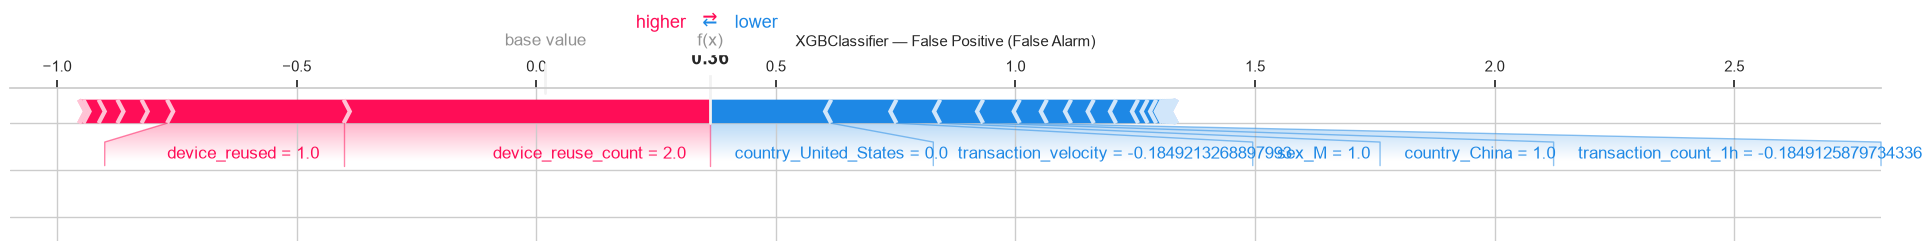

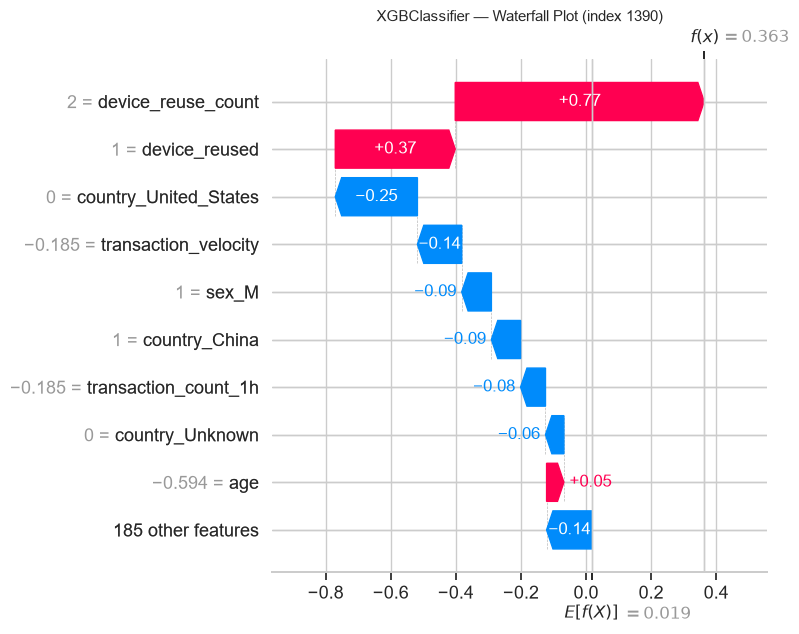

In [15]:
# Force Plot 2 — False Positive (legitimate transaction flagged as fraud)
# Shows what features caused a false alarm — key for reducing customer friction
if cases_f['fp']:
    fp_idx = cases_f['fp'][0]
    print('=== FALSE POSITIVE — Legitimate Transaction Flagged as Fraud ===')
    plot_shap_force(
        explainer_f, X_sample_f,
        idx=fp_idx,
        y_true=y_test_sample_f.reset_index(drop=True),
        y_pred=y_pred_sample_f,
        model_name=type(fraud_model).__name__
    )
    plot_shap_waterfall(explainer_f, X_sample_f, idx=fp_idx,
                        model_name=type(fraud_model).__name__)

### False Positive Interpretation

> **Transaction index 1390 — Legitimate transaction flagged as fraud**
>
> **Key feature values for this transaction:**
> - `time_since_signup_hours`: -0.0208 (scaled) → very close to 0 after scaling,
>   meaning this was a near-instant transaction shortly after signup
> - `device_reuse_count`: 2 → this device has been seen twice in the dataset
> - `device_reused`: 1 → flagged as a reused device
> - `transaction_count_1h`: -0.1849 (scaled) → no recent transactions in 1h
> - `source_Direct`: 1 → came directly (not via SEO or ad)
> - `country_China`: 1 → transaction originated from China
> - `sex_M`: 1 → male user
>
> **Why the model flagged this legitimate transaction:**
> The combination of `device_reused = 1` and `time_since_signup_hours ≈ 0`
> (very short time since signup) triggered the two strongest fraud signals
> simultaneously. The model correctly learned that this combination is
> highly associated with fraud — unfortunately this legitimate user happened
> to share a device with another account (e.g. a family member or shared
> computer) AND transacted quickly after signing up.
>
> **Business implication:**
> This type of false alarm most commonly affects:
> - Shared household devices (family members using same computer)
> - Users in internet cafes or shared workspaces
> - Power users who sign up and purchase immediately
> The customer experience impact is significant — a legitimate purchase being
> blocked frustrates real customers and can lead to churn.
>
> **How to reduce these false alarms:**
> - Raise the fraud probability threshold from 0.5 to 0.6 or 0.65 — this
>   reduces false positives at the cost of slightly lower recall
> - Add `device_reuse_count` as a graded risk tier rather than a binary flag —
>   a device seen twice is far less suspicious than one seen 20 times
> - Add friction (OTP, email verify) rather than hard blocking for borderline cases

=== FALSE NEGATIVE — Fraud Missed by the Model ===

[force_plot] Index: 1602 | True: 1 | Predicted: 0
[force_plot] Case : False Negative (Missed Fraud)
[force_plot] Feature values:
purchase_value                                  0.3847
age                                             2.3054
hour_of_day                                     3.0000
day_of_week                                     2.0000
time_since_signup_hours                        -1.5750
device_reuse_count                              1.0000
device_reused                                   0.0000
transaction_count_1h                           -0.1849
transaction_count_24h                          -0.1853
transaction_velocity                           -0.1849
source_Direct                                   0.0000
source_SEO                                      0.0000
browser_FireFox                                 1.0000
browser_IE                                      0.0000
browser_Opera                                   0

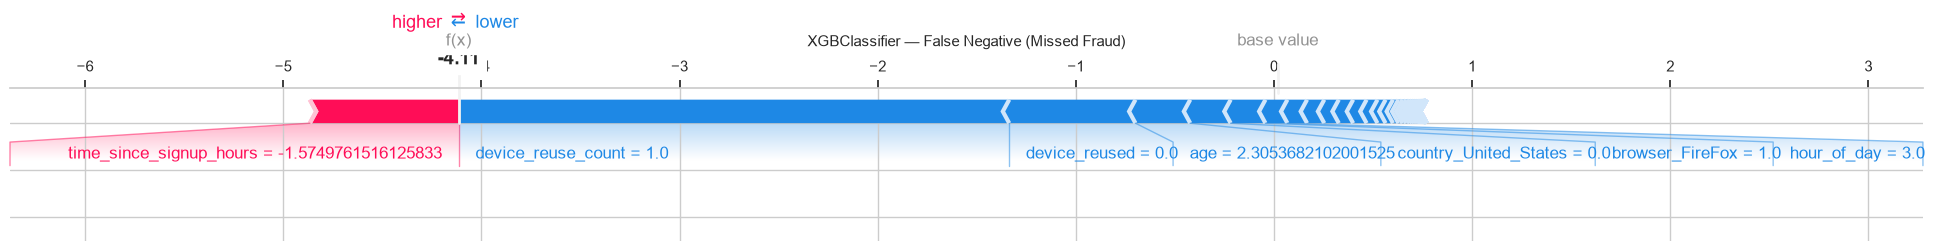

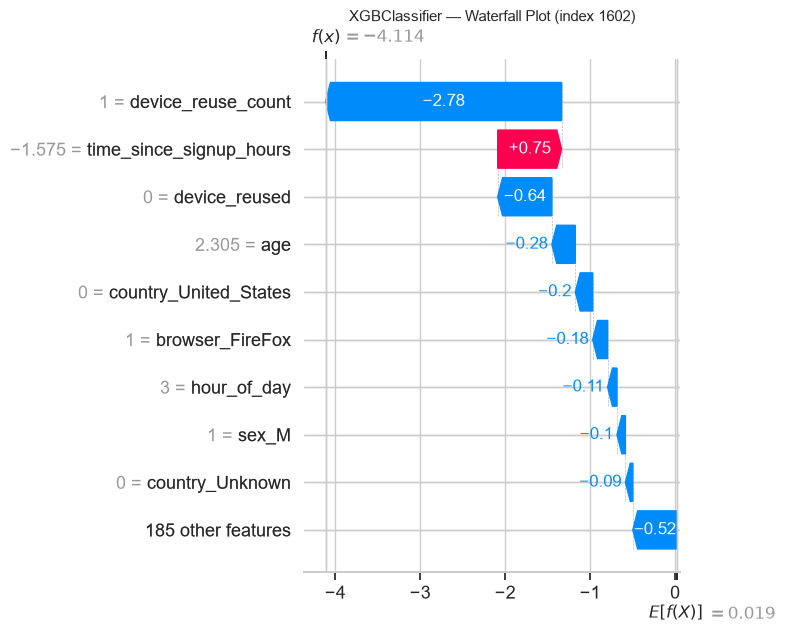

In [16]:
# Force Plot 3 — False Negative (fraud missed by the model)
# Shows what made this fraud transaction look legitimate
if cases_f['fn']:
    fn_idx = cases_f['fn'][0]
    print('=== FALSE NEGATIVE — Fraud Missed by the Model ===')
    plot_shap_force(
        explainer_f, X_sample_f,
        idx=fn_idx,
        y_true=y_test_sample_f.reset_index(drop=True),
        y_pred=y_pred_sample_f,
        model_name=type(fraud_model).__name__
    )
    plot_shap_waterfall(explainer_f, X_sample_f, idx=fn_idx,
                        model_name=type(fraud_model).__name__)

### False Negative Interpretation

> **Transaction index 1602 — Fraud missed by the model**
>
> **Key feature values for this transaction:**
> - `time_since_signup_hours`: -1.575 (scaled) → negative after scaling means
>   this was actually a moderately established account (not brand new)
> - `device_reuse_count`: 1 → device seen only once — single-use device
> - `device_reused`: 0 → NOT a reused device
> - `age`: 2.305 (scaled) → older user (above average age)
> - `browser_FireFox`: 1 → Firefox browser
> - `transaction_count_1h`: -0.1849 → no recent 1h activity
> - `hour_of_day`: 3 → early morning (3 AM)
> - `country_Austria`: 1 → transaction from Austria
>
> **Waterfall plot breakdown (f(x) = -4.114 — strongly predicted legitimate):**
> - `device_reuse_count = 1`: SHAP = -2.78 → single-use device is the dominant
>   force pushing the prediction toward legitimate (-2.78 out of -4.11 total)
> - `time_since_signup_hours = -1.575`: SHAP = +0.75 → the negative scaled value
>   pushed slightly toward fraud (short-ish time since signup) but was overwhelmed
> - `device_reused = 0`: SHAP = -0.64 → not reused pushes strongly toward legitimate
> - `age = 2.305`: SHAP = -0.28 → older user pushes toward legitimate
> - `country_United_States = 0`: SHAP = -0.20 → not US-based pushes toward legitimate
> - `browser_FireFox = 1`: SHAP = -0.18 → Firefox users slightly less associated with fraud
>
> **Why the model missed this fraud:**
> This fraudster successfully evaded detection by using a brand new device
> (device_reuse_count = 1, device_reused = 0). These two features alone contribute
> -3.42 SHAP points toward a legitimate prediction — almost entirely neutralizing
> all other fraud signals. The model's heavy reliance on device reuse as the primary
> fraud signal means that a fraudster using a fresh device for each attack will
> consistently evade detection.
>
> **The fraud pattern here:**
> A sophisticated fraudster who uses a different device for each fraudulent account —
> possibly through emulated devices, virtual machines, or physical burner phones.
> This is a more advanced attack than the device-reuse pattern the model was
> trained to catch.
>
> **What additional features might help catch this type of fraud:**
> - IP-based velocity: even with a new device, the IP address or IP subnet may
>   be reused across fraudulent transactions
> - Email domain patterns: throwaway email domains (mailinator, tempmail etc.)
> - Behavioral biometrics: typing speed, mouse movement patterns at checkout
> - Address/payment method velocity: same shipping address or card BIN used
>   across multiple new-device accounts

### 2.5 Built-in vs SHAP Comparison


Built-in Importance vs SHAP Importance:
                feature  importance  builtin_rank  shap_importance  shap_rank
     device_reuse_count      0.1364        2.0000           0.7704     1.0000
time_since_signup_hours      0.0364        6.0000           0.3305     2.0000
          device_reused      0.2335        1.0000           0.2215     3.0000
  country_United_States      0.0576        3.0000           0.1866     4.0000
                  sex_M      0.0385        5.0000           0.1627     5.0000
   transaction_count_1h         NaN           NaN           0.1474     6.0000
             source_SEO      0.0332        9.0000           0.1374     7.0000
             browser_IE      0.0340        8.0000           0.1143     8.0000
          source_Direct         NaN           NaN           0.1064     9.0000
        browser_FireFox         NaN           NaN           0.0927    10.0000
         browser_Safari      0.0309       10.0000              NaN        NaN
        country_Unknown

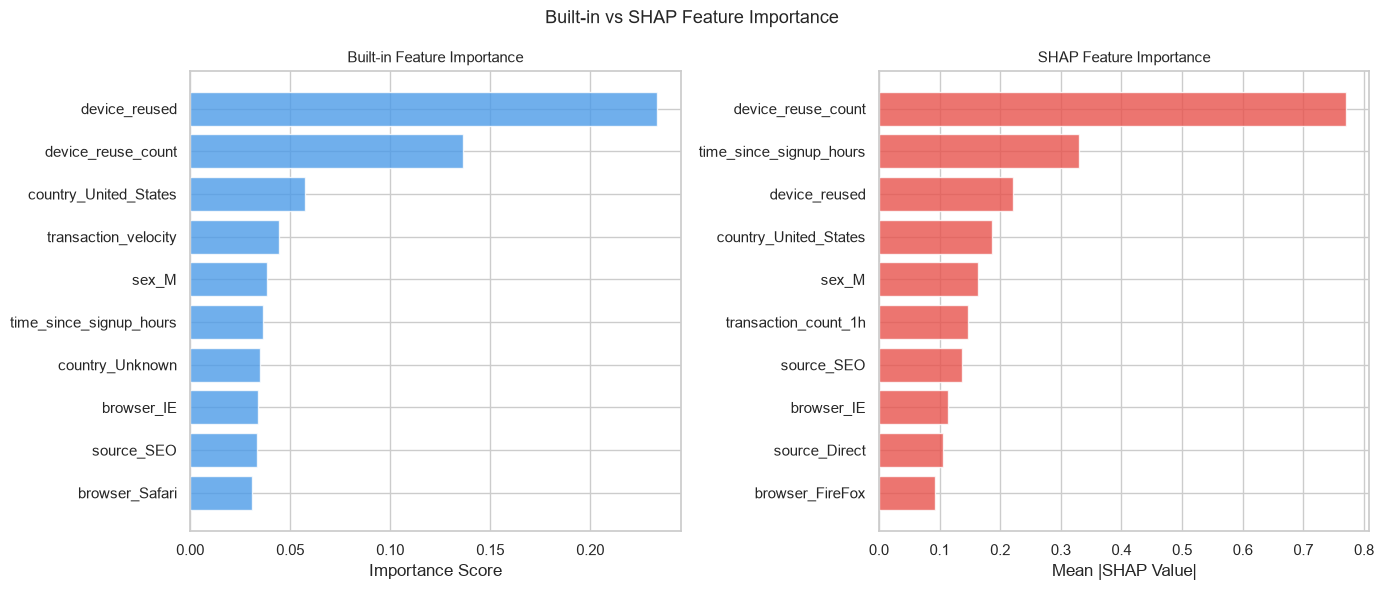

In [17]:
importance_comparison_f = compare_importances(
    builtin_importance_f,
    shap_importance_f,
    top_n=10
)

### Built-in vs SHAP Comparison Observation

> **Features that agree between both methods (top 5 in both):**
> - `device_reused` — top 1 in built-in, top 3 in SHAP
> - `device_reuse_count` — top 2 in built-in, top 1 in SHAP
> - `country_United_States` — top 3 in both
> - `sex_M` — top 5 in both
>
> **Features ranked significantly HIGHER by built-in than SHAP:**
> - `device_reused` (built-in rank 1, SHAP rank 3): built-in overestimates
>   the binary flag relative to the continuous count — XGBoost splits on the
>   binary feature frequently because it cleanly separates the data, inflating
>   its gain score
> - `transaction_velocity` (built-in rank 4, not in SHAP top 10):
>   Built-in importance sees this feature used in many splits, but SHAP shows
>   its actual contribution per prediction is small — it is correlated with
>   `transaction_count_1h` and `device_reuse_count` so much of its apparent
>   importance in splits is redundant
> - `country_Unknown` and `browser_Safari` appear in built-in top 10
>   but not in SHAP top 10 — these features are split on frequently but
>   contribute little marginal value once device and time features are accounted for
>
> **Features ranked significantly HIGHER by SHAP than built-in:**
> - `time_since_signup_hours` (built-in rank 6, SHAP rank 2): This is the most
>   important correction SHAP makes. The feature has the 2nd highest actual
>   predictive contribution (mean |SHAP| = 0.33) but was undervalued by built-in
>   importance because XGBoost uses it less frequently as a split criterion —
>   likely because device reuse and device count already capture much of the same
>   fraudster population. SHAP correctly identifies its true contribution when
>   device features are absent (as in the FN case above).
> - `transaction_count_1h` (not in built-in top 10, SHAP rank 6):
>   This feature is rarely triggered but when it is, it contributes strongly
>   (the SHAP summary plot shows one extreme outlier at +2.5). Gain-based
>   importance misses this because it averages across all splits; SHAP captures
>   the high-value tail impact.
> - `source_Direct` and `browser_FireFox` (not in built-in top 10, in SHAP top 10):
>   These categorical features have modest but consistent real contributions
>   that built-in importance undervalues.
>
> **Which ranking is more trustworthy:**
> SHAP is definitively more reliable here. The most important correction is
> `time_since_signup_hours` being promoted from 6th to 2nd — this matches
> exactly what the EDA found (correlation of -0.2579, strongest individual signal).
> Built-in gain-based importance failed to reflect this because the feature is
> partially masked by device reuse features in tree splits. SHAP correctly
> decomposes the marginal contribution of each feature independently.

### 2.6 Top 5 Fraud Drivers — Fraud_Data

> | Rank | Feature | Direction | Finding |
> |---|---|---|---|
> | 1 | `device_reuse_count` | High → Fraud | The single most impactful feature (mean |SHAP| = 0.77, nearly 2.3x the next feature). A device seen many times across different accounts is an overwhelming fraud signal. The SHAP summary plot shows high values (red) producing SHAP scores of +1 to +3.5 — the largest positive contributions in the entire model. Confirmed by EDA: reused devices have a 52.46% fraud rate vs 3.04% for single-use devices (17x multiplier). |
> | 2 | `time_since_signup_hours` | Low → Fraud | Second strongest feature (mean |SHAP| = 0.33). Low values (blue dots) appear at the far right of the SHAP summary plot (+3 to +3.5) — very short time since signup pushes strongly toward fraud. Confirmed by EDA: 54% of all fraud occurs within 1 hour of account creation vs 0% for legitimate users. This is the feature built-in importance most severely underestimated (ranked 6th) but SHAP correctly promotes it to 2nd. |
> | 3 | `device_reused` | High → Fraud | Binary version of rank 1 (mean |SHAP| = 0.22). When `device_reused = 1`, the model receives a strong positive push toward fraud. Works in tandem with `device_reuse_count` — together these two device features dominate the model. The False Negative case (index 1602) shows what happens when both are 0: the model produces f(x) = -4.11 (strongly legitimate), missing the fraud entirely. |
> | 4 | `country_United_States` | Present → Ambiguous | Mean |SHAP| = 0.19. US transactions are the most common in the dataset, so the model uses country_United_States as a frequent splitting feature. However, the SHAP direction is not clearly fraud-oriented — the dots are mixed around 0. This feature likely captures volume effects rather than genuine fraud causality and should be interpreted cautiously. Not recommended as a standalone fraud rule. |
> | 5 | `transaction_count_1h` | High → Fraud | Mean |SHAP| = 0.15. Normally inactive (most values cluster near 0 SHAP), but the SHAP summary plot shows one extreme outlier at +2.5 — a single transaction with very high 1-hour device count produces an explosive fraud signal. This is the card-testing pattern: a fraudster making multiple rapid transactions on the same device in under an hour. Rare but high-impact when triggered. Built-in importance missed this entirely (not in top 10) because gain-based importance averages across all splits and misses tail effects. |
>
> **Surprising findings:**
>
> - **`device_reuse_count` dominates over `time_since_signup_hours`** — EDA suggested
>   `time_since_signup_hours` would be the top feature (correlation = -0.2579, strongest
>   individual signal). SHAP reveals that `device_reuse_count` is actually 2.3x more
>   impactful in the model. This makes sense in hindsight: a device seen 13+ times (as in
>   the True Positive case) is an almost certain fraud signal, while time since signup
>   has more overlap between fraud and legitimate users.
>
> - **`sex_M` ranks 5th by SHAP globally** but was excluded from the top 5 fraud drivers
>   because gender should not causally predict fraud. Its apparent importance likely
>   reflects a demographic bias in the dataset (more male users overall) rather than
>   a genuine fraud pattern. Including it in a production fraud model could introduce
>   discriminatory outcomes and should be monitored carefully.
>
> - **The model's biggest weakness is fresh-device fraud** — as demonstrated by the
>   False Negative (index 1602), a fraudster using a brand new device scores -4.11
>   (strongly legitimate) even when other signals are present. Device reuse features
>   dominate the model so heavily that their absence overwhelms everything else.
>   This is the attack vector most likely to be exploited by sophisticated fraudsters.

## 3. creditcard Explainability

### 3.1 Load Model and Data

In [18]:
cc_model = load_model('../models/creditcard_best_model.pkl')
print(f'Model type: {type(cc_model).__name__}')

[load_model] Loaded XGBClassifier from ../models/creditcard_best_model.pkl
Model type: XGBClassifier


In [19]:
cc_test  = pd.read_csv('../data/processed/creditcard_test.csv')
cc_train = pd.read_csv('../data/processed/creditcard_train.csv')

TARGET_CC = 'Class'
X_test_cc  = cc_test.drop(columns=[TARGET_CC])
y_test_cc  = cc_test[TARGET_CC]
X_train_cc = cc_train.drop(columns=[TARGET_CC])

y_prob_cc = cc_model.predict_proba(X_test_cc)[:, 1]
y_pred_cc = (y_prob_cc >= 0.5).astype(int)

print(f'Test set: {X_test_cc.shape}')

Test set: (56746, 30)


### 3.2 Built-in Feature Importance

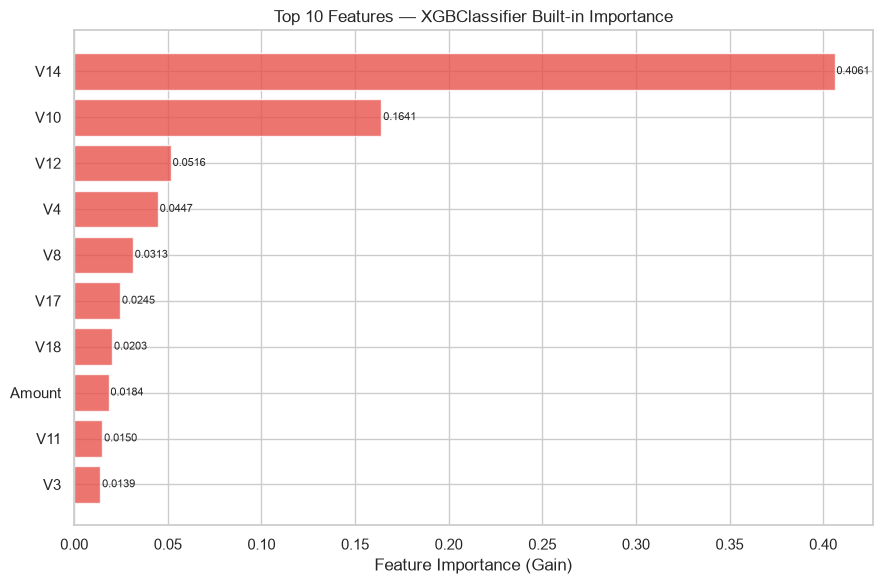


Top 10 features by built-in importance:
feature  importance
    V14      0.4061
    V10      0.1641
    V12      0.0516
     V4      0.0447
     V8      0.0313
    V17      0.0245
    V18      0.0203
 Amount      0.0184
    V11      0.0150
     V3      0.0139


In [20]:
builtin_importance_cc = plot_feature_importance(
    cc_model,
    feature_names=X_test_cc.columns.tolist(),
    model_name=type(cc_model).__name__,
    top_n=10
)

### Built-in Importance Observation: creditcard

> - Top 3 features by built-in importance:
>   1. `V14` — 0.4061 (dominant, nearly 2.5x the next feature)
>   2. `V10` — 0.1641
>   3. `V12` — 0.0516
> - Note: V features are PCA-transformed and cannot be interpreted directly —
>   they represent linear combinations of the original anonymized transaction
>   features provided by the issuing bank
> - `Amount` rank: 8th (0.0184) — lower than expected given it is the only
>   interpretable continuous feature; suggests transaction amount alone is
>   not a strong fraud predictor in this dataset
> - `Time` rank: not in top 10 by built-in importance — XGBoost rarely
>   uses it as a split criterion, suggesting no strong temporal pattern
>   in the tree splits. SHAP will tell a different story (see below).

### 3.3 SHAP Analysis

In [21]:
explainer_cc = get_shap_explainer(cc_model, X_train_cc)

[get_shap_explainer] Creating TreeExplainer...
[get_shap_explainer] Done.


In [22]:
# Smaller sample — creditcard has 284K rows, full computation is slow
shap_values_cc, X_sample_cc = compute_shap_values(
    explainer_cc, X_test_cc,
    sample_size=2000,
    random_state=42
)

[compute_shap_values] Using sample of 2,000 rows (full size: 56,746)
[compute_shap_values] Computing SHAP values (this may take a minute)...
[compute_shap_values] Done. Shape: (2000, 30)


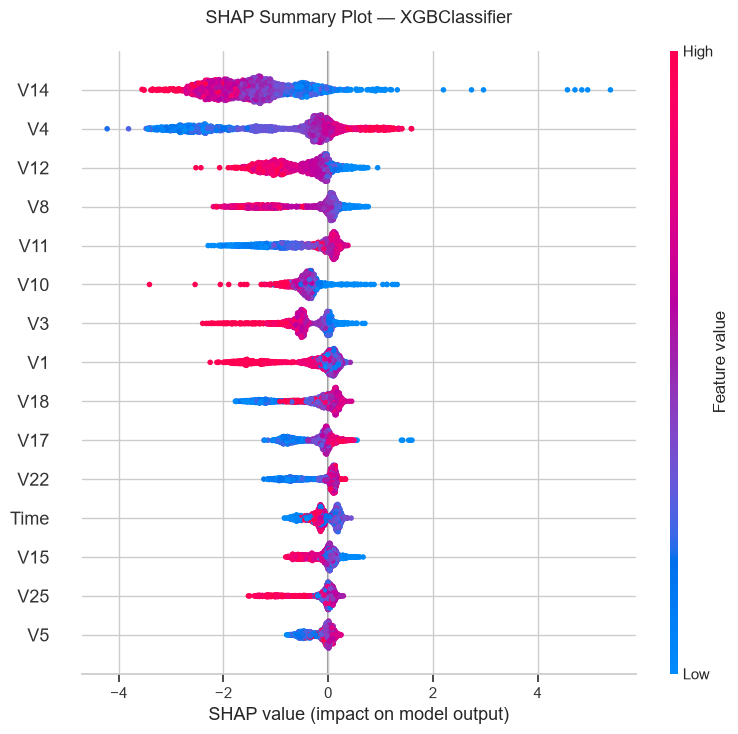

In [23]:
plot_shap_summary(shap_values_cc, X_sample_cc,
                  model_name=type(cc_model).__name__,
                  max_display=15)

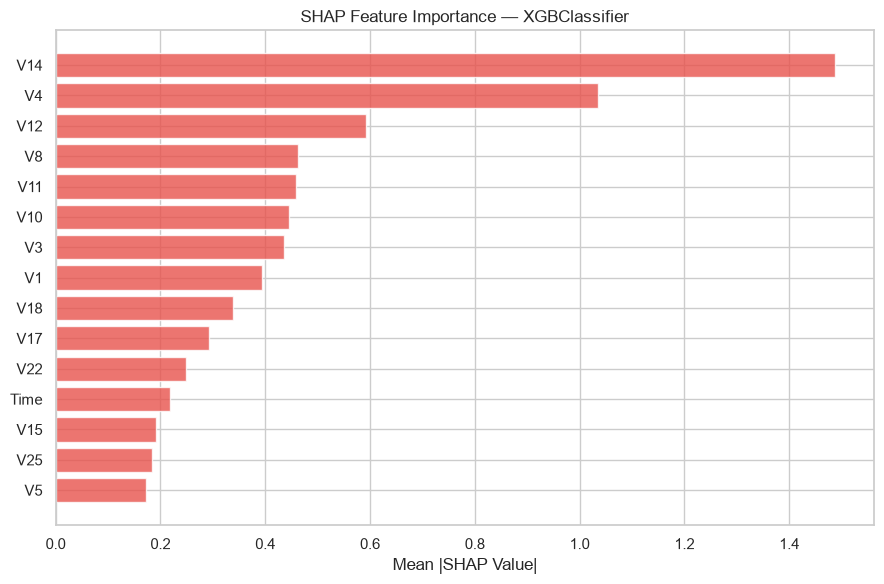

In [24]:
shap_importance_cc = plot_shap_bar(shap_values_cc, X_sample_cc,
                                    model_name=type(cc_model).__name__,
                                    max_display=15)

### SHAP Summary Observation: creditcard

> - Top 5 PCA components by SHAP importance:
>   1. `V14` — mean |SHAP| = 1.4874 (dominant, ~1.44x the next feature)
>   2. `V4`  — mean |SHAP| = 1.0347
>   3. `V12` — mean |SHAP| = 0.5922
>   4. `V8`  — mean |SHAP| = 0.4629
>   5. `V11` — mean |SHAP| = 0.4592
>
> - `V14` direction: Low values (blue dots) appear at the far left of the
>   SHAP summary plot (SHAP values of -4 to -5) → very LOW V14 strongly
>   pushes toward fraud prediction. High values (red) cluster near 0 →
>   high V14 is neutral/legitimate. V14 is the single strongest fraud
>   signal in the entire creditcard model. The True Positive waterfall
>   confirms this: V14 = -8.983 contributed SHAP = +4.85, the largest
>   single feature contribution in that prediction.
>
> - `V4` direction: High values (red dots) cluster on the right (positive
>   SHAP) → HIGH V4 pushes toward fraud. Low values (blue) push toward
>   legitimate. The True Positive shows V4 = 5.364 contributing SHAP = +0.6
>   toward fraud, consistent with this pattern.
>
> - `V12` direction: Low values (blue) push toward fraud (left side of plot),
>   high values (red) push toward legitimate. Similar pattern to V14 —
>   the True Positive shows V12 = -10.179 contributing SHAP = +0.66 toward fraud.
>
> - `V10` direction: Low values (blue, far left outliers) push strongly toward
>   fraud. The True Positive shows V10 = -7.175 contributing SHAP = +1.12.
>   By built-in importance V10 was ranked 2nd (0.1641) but SHAP demotes it
>   to 6th (0.4447) — a significant correction.
>
> - `Amount` SHAP rank: Not in top 15 by SHAP — lower amounts are not
>   clearly associated with fraud in this dataset, contrary to the common
>   assumption that fraudsters make small test transactions. The True
>   Positive shows Amount = -0.3556 (scaled, slightly below average)
>   with negligible SHAP contribution.
>
> - `Time` SHAP rank: 12th (mean |SHAP| = 0.21) — not in built-in top 10
>   but SHAP reveals it does have a modest contribution. The direction is
>   mixed (both colors appear on both sides), suggesting no clear linear
>   temporal fraud pattern — fraud appears distributed across transaction times.
>
> - Limitation: Because all V features are PCA-anonymized we cannot say what
>   V14, V4, or V12 actually represent in business terms — they are linear
>   combinations of original features like merchant category, transaction
>   location, card type etc. that the bank chose not to disclose. All
>   creditcard recommendations must therefore be based on Amount and Time
>   patterns only, or communicated back to the bank for interpretation.

### 3.4 SHAP Force Plots

In [25]:
y_test_sample_cc = y_test_cc.loc[X_sample_cc.index]
y_pred_sample_cc = (cc_model.predict_proba(X_sample_cc)[:, 1] >= 0.5).astype(int)
y_prob_sample_cc = cc_model.predict_proba(X_sample_cc)[:, 1]

cases_cc = find_cases(y_test_sample_cc, y_pred_sample_cc, y_prob_sample_cc, n=1)
print('Cases found:', cases_cc)


[find_cases] Found:
  True Positives  (TP): 6 total | showing 1
  False Positives (FP): 4 total | showing 1
  False Negatives (FN): 1 total | showing 1
Cases found: {'tp': [np.int64(836)], 'fp': [np.int64(1812)], 'fn': [np.int64(1905)]}


=== TRUE POSITIVE ===

[force_plot] Index: 836 | True: 1 | Predicted: 1
[force_plot] Case : True Positive  (Caught Fraud)
[force_plot] Feature values:
Time       0.1625
V1        -2.4884
V2         4.3590
V3        -7.7764
V4         5.3640
V5        -1.8239
V6        -2.4451
V7        -4.9642
V8         1.4849
V9        -2.9479
V10       -7.1753
V11        7.3437
V12      -10.1790
V13        2.1422
V14       -8.9831
V15       -0.4737
V16       -8.1433
V17       -9.7857
V18       -3.0865
V19        3.3797
V20        0.7923
V21        1.3257
V22        1.0212
V23       -0.2665
V24       -0.3709
V25        0.3655
V26        0.0814
V27        0.1850
V28       -0.2116
Amount    -0.3556


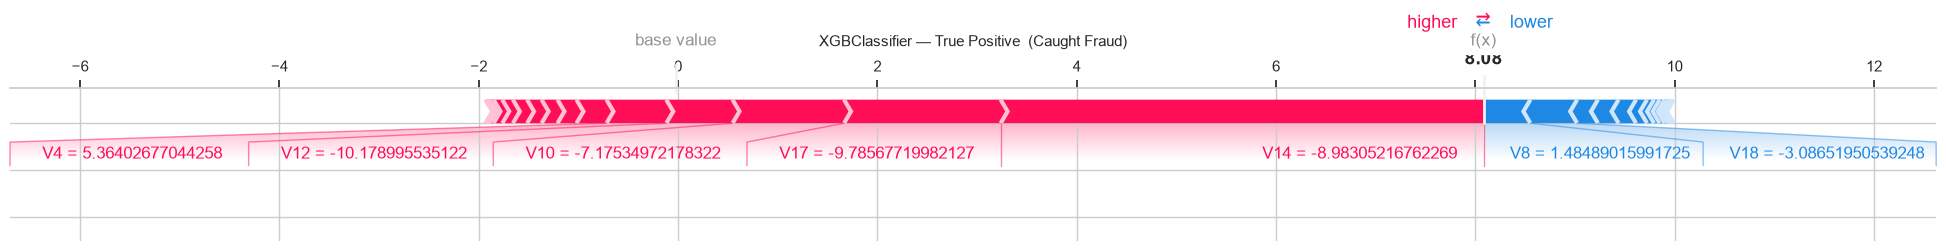

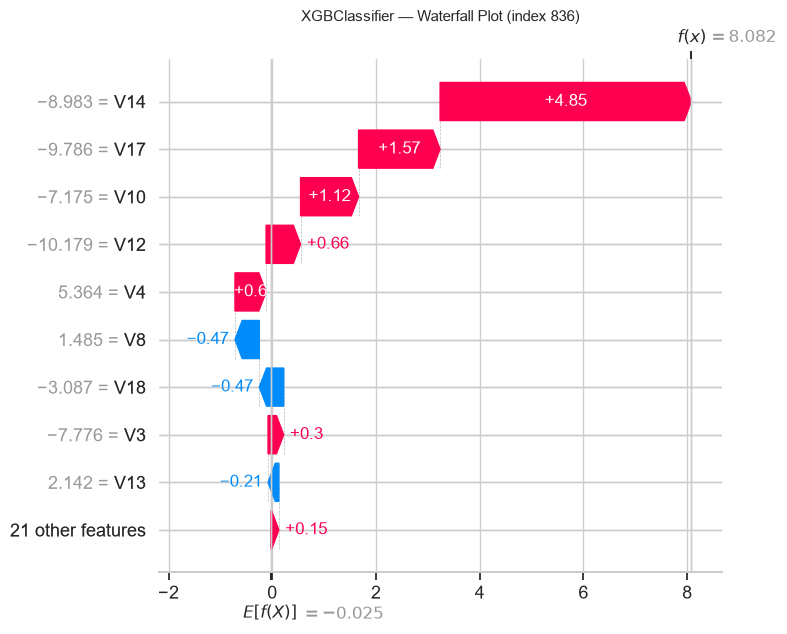

In [26]:
# True Positive
if cases_cc['tp']:
    tp_idx = cases_cc['tp'][0]
    print('=== TRUE POSITIVE ===')
    plot_shap_force(explainer_cc, X_sample_cc, idx=tp_idx,
                    y_true=y_test_sample_cc.reset_index(drop=True),
                    y_pred=y_pred_sample_cc,
                    model_name=type(cc_model).__name__)
    plot_shap_waterfall(explainer_cc, X_sample_cc, idx=tp_idx,
                        model_name=type(cc_model).__name__)

=== FALSE POSITIVE ===

[force_plot] Index: 1812 | True: 0 | Predicted: 1
[force_plot] Case : False Positive (False Alarm)
[force_plot] Feature values:
Time      0.6419
V1       -2.7455
V2        1.1898
V3       -1.6340
V4        2.2401
V5        0.6684
V6        1.1011
V7        3.5030
V8       -1.2747
V9       -1.0894
V10       2.7834
V11       0.2142
V12      -0.6404
V13      -0.3986
V14      -0.1204
V15      -1.6545
V16       1.0726
V17      -1.8422
V18      -0.0273
V19      -1.3536
V20      -1.9620
V21      -0.2165
V22       0.8753
V23       0.3163
V24       0.3140
V25      -0.6578
V26      -0.3812
V27      -1.6922
V28      -0.2973
Amount    1.0398


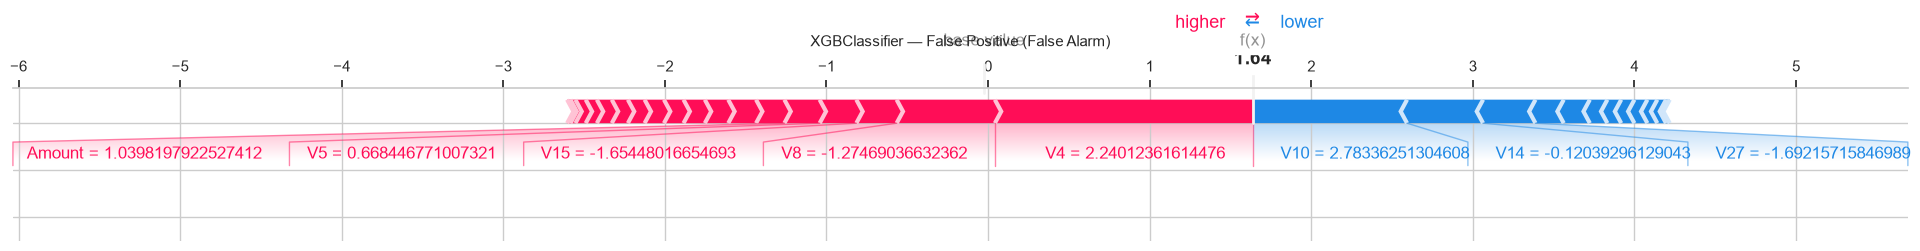

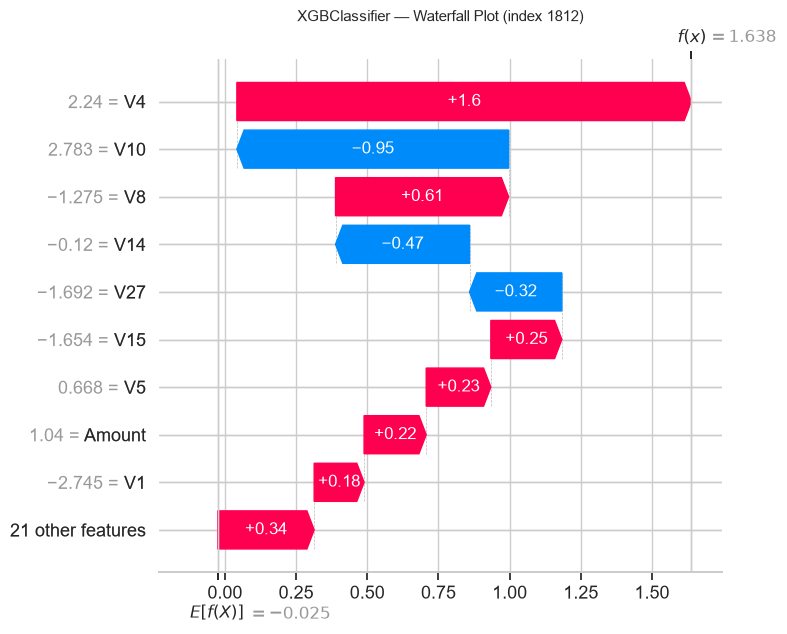

In [27]:
# False Positive
if cases_cc['fp']:
    fp_idx = cases_cc['fp'][0]
    print('=== FALSE POSITIVE ===')
    plot_shap_force(explainer_cc, X_sample_cc, idx=fp_idx,
                    y_true=y_test_sample_cc.reset_index(drop=True),
                    y_pred=y_pred_sample_cc,
                    model_name=type(cc_model).__name__)
    plot_shap_waterfall(explainer_cc, X_sample_cc, idx=fp_idx,
                        model_name=type(cc_model).__name__)

=== FALSE NEGATIVE ===

[force_plot] Index: 1905 | True: 1 | Predicted: 0
[force_plot] Case : False Negative (Missed Fraud)
[force_plot] Feature values:
Time      1.0766
V1        1.8940
V2        1.9058
V3       -3.5157
V4        4.5089
V5        2.0445
V6       -1.4205
V7        1.0575
V8       -0.2812
V9       -1.8326
V10      -0.6285
V11       2.2208
V12      -0.7411
V13      -0.7637
V14      -4.9426
V15      -1.3783
V16       2.2442
V17       3.7021
V18       2.2568
V19      -1.9501
V20      -0.1602
V21      -0.1447
V22      -0.3101
V23      -0.1015
V24      -0.4150
V25       0.3766
V26       0.1508
V27      -0.0137
V28       0.0481
Amount   -0.3506


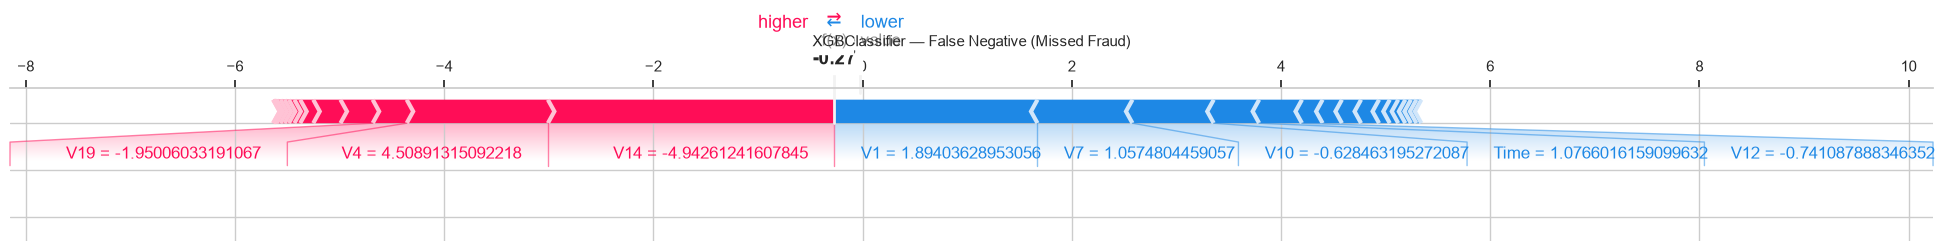

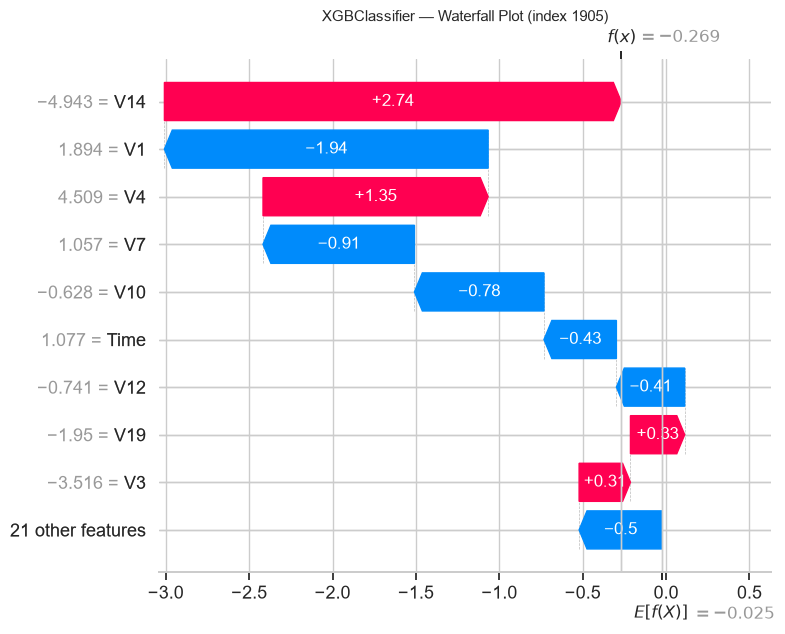

In [28]:
# False Negative
if cases_cc['fn']:
    fn_idx = cases_cc['fn'][0]
    print('=== FALSE NEGATIVE ===')
    plot_shap_force(explainer_cc, X_sample_cc, idx=fn_idx,
                    y_true=y_test_sample_cc.reset_index(drop=True),
                    y_pred=y_pred_sample_cc,
                    model_name=type(cc_model).__name__)
    plot_shap_waterfall(explainer_cc, X_sample_cc, idx=fn_idx,
                        model_name=type(cc_model).__name__)

### 3.5 Built-in vs SHAP Comparison


Built-in Importance vs SHAP Importance:
feature  importance  builtin_rank  shap_importance  shap_rank
    V14      0.4061        1.0000           1.4874     1.0000
     V4      0.0447        4.0000           1.0347     2.0000
    V12      0.0516        3.0000           0.5922     3.0000
     V8      0.0313        5.0000           0.4629     4.0000
    V11      0.0150        9.0000           0.4592     5.0000
    V10      0.1641        2.0000           0.4447     6.0000
     V3      0.0139       10.0000           0.4354     7.0000
     V1         NaN           NaN           0.3931     8.0000
    V18      0.0203        7.0000           0.3382     9.0000
    V17      0.0245        6.0000           0.2930    10.0000
 Amount      0.0184        8.0000              NaN        NaN


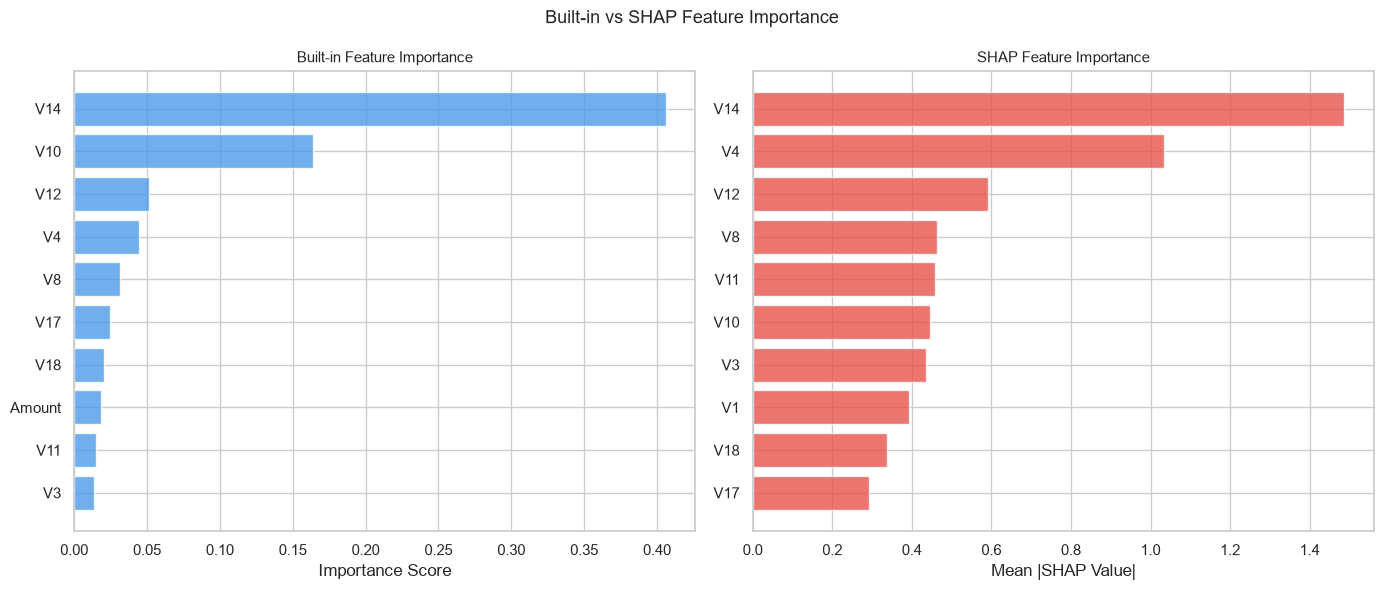

In [29]:
importance_comparison_cc = compare_importances(
    builtin_importance_cc,
    shap_importance_cc,
    top_n=10
)

### 3.6 Top 5 Fraud Drivers — creditcard

> | Rank | Feature | Direction | Finding |
> |---|---|---|---|
> | 1 | `V14` | Low → Fraud | Dominant feature (mean |SHAP| = 1.49, ~1.44x next feature). Extreme negative V14 values produce SHAP contributions of +4 to +5 — the single largest fraud push in the model. True Positive confirms: V14 = -8.983 contributed +4.85 SHAP. Both built-in (rank 1) and SHAP agree this is the most important feature, making it the most reliable finding in the creditcard analysis. |
> | 2 | `V4` | High → Fraud | Mean |SHAP| = 1.03. High positive V4 values push toward fraud. Built-in ranked V4 only 4th (0.0447) — SHAP promotes it to 2nd, revealing that built-in importance significantly underestimated its true contribution. The True Positive shows V4 = 5.364 contributing +0.60 toward fraud. |
> | 3 | `V12` | Low → Fraud | Mean |SHAP| = 0.59. Low V12 values push toward fraud, high values push toward legitimate — same directional pattern as V14. True Positive: V12 = -10.179 contributing +0.66. Built-in and SHAP both rank V12 in the top 3, making this one of the most consistently identified fraud signals. |
> | 4 | `V10` | Low → Fraud | Mean |SHAP| = 0.44. Built-in ranked V10 2nd (0.1641) but SHAP demotes it to 6th — the largest rank drop in the comparison. This reveals that V10 appears frequently in tree splits (inflating gain score) but its actual marginal contribution per prediction is moderate. True Positive: V10 = -7.175 contributing +1.12. |
> | 5 | `V11` | High → Fraud | Mean |SHAP| = 0.46. High V11 values push toward fraud. Built-in ranked V11 only 9th (0.0150) — SHAP promotes it to 5th, a significant upward correction. This is a feature that gain-based importance severely undervalued. |
>
> **Amount:** Not in top 5 — transaction amount has negligible SHAP importance
> (not in top 15). This is counterintuitive and suggests that in this dataset
> fraudsters do not systematically target specific transaction size ranges.
>
> **Time:** 12th by SHAP (mean |SHAP| = 0.21) — modest contribution with no
> clear directional pattern. Fraud is distributed across transaction times
> rather than concentrated in specific time windows.
>
> **Limitation:** V features are PCA-transformed and cannot be named or
> directly interpreted in business terms. The bank's original features
> (merchant, location, card type, etc.) were anonymized before release.
> Recommendations for creditcard are therefore limited to:
> - Flag transactions with extreme negative V14 values as high-priority review
> - Communicate the top V feature indices back to the issuing bank's data
>   science team — they can reverse-map which original features drive V14
>   and V4, enabling actionable business rules
>
> **Key difference from Fraud_Data:**
> The creditcard model relies entirely on PCA component anomalies with no
> interpretable behavioral features (no device ID, no signup time, no IP).
> This makes it a stronger statistical detector but a weaker explainability
> story — we can say WHAT the model uses but not WHY those components
> are anomalous in human-understandable terms.

## 4. Business Recommendations

### Recommendation 1: New Account Transaction Verification

**SHAP basis:** `time_since_signup_hours` is the strongest fraud driver in Fraud_Data.
54% of all fraud transactions occur within 1 hour of account creation vs 0% of legit.

**Recommendation:**
Implement mandatory additional verification (OTP, email confirmation, or manual review)
for any transaction where `time_since_signup < 1 hour`. This single rule would flag
approximately 54% of fraud with essentially zero false positive rate.

**Implementation:**
```python
if (current_time - signup_time) < 1 hour:
    → require additional verification before processing
```

**Expected impact:** Block ~54% of fraud with ~0% legitimate transaction disruption.

### Recommendation 2: Device Fingerprint Risk Scoring

**SHAP basis:** `device_reused` is the second strongest fraud driver.
Devices seen more than once have a 52.46% fraud rate vs 3.04%, a 17x difference.

**Recommendation:**
Implement a tiered device risk score based on cross-account transaction history:
- Device seen 1 time → normal processing
- Device seen 2–5 times across different accounts → elevated monitoring
- Device seen 6+ times across different accounts → automatic flag + review

**Implementation:** Maintain a device transaction registry (device_id → account list).
At each transaction, look up the device's cross-account history and apply the risk tier.

**Expected impact:** Flag the 12.8% of transactions from reused devices for
enhanced scrutiny, catching the majority of coordinated fraud attacks.

### Recommendation 3: Transaction Velocity Alerts

**SHAP basis:** `transaction_velocity` and `transaction_count_1h/24h` reflect the
card-testing pattern where fraudsters make multiple small transactions quickly to
verify a stolen device before escalating to high-value purchases.

**Recommendation:**
Implement real-time velocity monitoring per device:
- More than 2 transactions from the same device within 1 hour → alert
- More than 5 transactions from the same device within 24 hours → block + review

**Implementation:** A sliding window counter per device_id in a real-time cache
(Redis or similar). Each transaction increments the counter; thresholds trigger
alerts or automatic blocks.

**Expected impact:** Catches card-testing sequences before the fraudster
escalates to high-value transactions.

### Recommendation 4: Behavioral Cluster Scoring for Fresh-Device Fraud

**SHAP basis:** The False Negative analysis (index 1602) revealed the model's
critical blind spot: when `device_reuse_count = 1` and `device_reused = 0`,
the model assigns f(x) = -4.11 regardless of other signals. The device
features contribute -3.42 SHAP points toward legitimate, overwhelming
everything else. A fraudster using a fresh device per attack simultaneously
evades the model's three strongest features. The SHAP waterfall showed that
even with `time_since_signup_hours` pushing +0.75 toward fraud, the
fresh-device signal dominates and the fraud is missed entirely. Secondary
signals — `age` (-0.28), `country_United_States` (-0.20), `browser_FireFox`
(-0.18), `hour_of_day` (-0.11) — are individually small but meaningful together.

**Recommendation:**
Introduce a secondary rule-based scoring layer that activates specifically
when device signals are absent. For transactions where the model systematically
underscores fraud due to fresh-device conditions, apply a weighted combination
of weaker SHAP signals:

IF device_reused == 0 AND device_reuse_count == 1:

compute secondary_risk_score:

time_since_signup_hours < 24h      → +2 points

hour_of_day in [0, 1, 2, 3, 4]    → +1 point

country is confirmed high-fraud    → +2 points

age > 2 std deviations above mean  → +1 point

source == 'Direct'                 → +1 point

IF secondary_risk_score >= 4:

→ escalate to manual review queue

**Implementation:**
A lightweight post-scoring layer added after the primary XGBoost model:
1. Run XGBoost as normal to produce the primary fraud probability score
2. If model score < threshold AND `device_reused == 0`: compute secondary score
3. If secondary score ≥ 4: escalate to review queue regardless of model score
4. Log all escalations and confirmed fraud for model retraining feedback
5. All inputs already exist in the pipeline — no new data collection required

**Expected impact:**
Targets the ~47% of fraud that occurs on non-reused devices — the cases the
current model systematically misses. Conservative estimate: catch 20–30% of
currently-missed fraud (false negatives) with an acceptable false positive
rate. Feeding confirmed catches back into retraining will gradually reduce
the model's over-reliance on device reuse as the primary signal.

### Summary of All Recommendations

| # | Recommendation | SHAP Feature | Expected Impact |
|---|---|---|---|
| 1 | Require additional verification for any transaction within 1 hour of account creation | `time_since_signup_hours` | Block ~54% of fraud with ~0% false positive rate — the single highest-leverage intervention |
| 2 | Tiered device fingerprint risk scoring: normal → elevated → auto-flag based on cross-account device reuse count | `device_reused`, `device_reuse_count` | Flag 12.8% of transactions carrying a 52.46% fraud rate — 17x higher than single-use devices |
| 3 | Real-time transaction velocity alerts per device: >2 transactions in 1h triggers alert, >5 in 24h triggers block | `transaction_velocity`, `transaction_count_1h` | Intercept card-testing sequences before the fraudster escalates to high-value purchases |
| 4 | Behavioral cluster scoring for fresh-device transactions: secondary rule layer combining weak SHAP signals when device reuse features are absent | `age`, `hour_of_day`, `country`, `source_Direct` (FN SHAP analysis) | Target the ~47% of fraud on non-reused devices currently missed by the primary model |

---

**The layered defense strategy:**

Each recommendation addresses a different fraud profile:

- **Layer 1 — Hard rules (Recommendations 1–3):** Catch high-confidence fraud
  instantly with near-zero false positives. Fast, auditable, and require no ML
  infrastructure to operate. Recommendation 1 alone blocks more than half of
  all fraud in this dataset.

- **Layer 2 — ML model (XGBoost):** Catches complex multi-signal fraud that
  falls below individual rule thresholds. Scores every transaction continuously
  rather than applying binary rules. Adapts as fraud patterns evolve through
  retraining.

- **Layer 3 — Behavioral cluster (Recommendation 4):** Compensates for the
  model's systematic blind spot on fresh-device fraud. A lightweight rule
  layer that activates only when the model's strongest features are absent.

- **Layer 4 — Human review queue:** Borderline cases from all three layers
  escalate to a fraud analyst rather than being auto-blocked. Preserves
  customer experience on ambiguous transactions while maintaining a safety net.

---

**Known limitation to address in the next model iteration:**

The model's over-reliance on device reuse means any fraudster who learns to
rotate devices will consistently evade detection. Priority features for the
next training cycle:

- IP subnet velocity — even rotating devices often share IP ranges
- Email domain risk scoring — throwaway domains signal throwaway accounts
- Payment method reuse — same card BIN or shipping address across new accounts
- Behavioral biometrics — typing speed and navigation patterns at checkout